
[Bước 1] Tải dữ liệu video
Đang tải: https://github.com/lthavnu/cv-book/raw/main/images/anomaly/normal.mp4
Đã lưu: video_data/nomal.mp4
Đang tải: https://github.com/lthavnu/cv-book/raw/main/images/anomaly/anomaly.mp4
Đã lưu: video_data/anomaly.mp4

[Bước 2] Trích đặc trưng từ video bình thường
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]



[Bước 3] Tạo chuỗi train

[Bước 4] Huấn luyện LSTM Autoencoder
Epoch 01/10 - loss: 0.771444
Epoch 02/10 - loss: 0.637104
Epoch 03/10 - loss: 0.438575
Epoch 04/10 - loss: 0.300800
Epoch 05/10 - loss: 0.206179
Epoch 06/10 - loss: 0.159657
Epoch 07/10 - loss: 0.129423
Epoch 08/10 - loss: 0.100600
Epoch 09/10 - loss: 0.083696
Epoch 10/10 - loss: 0.068436


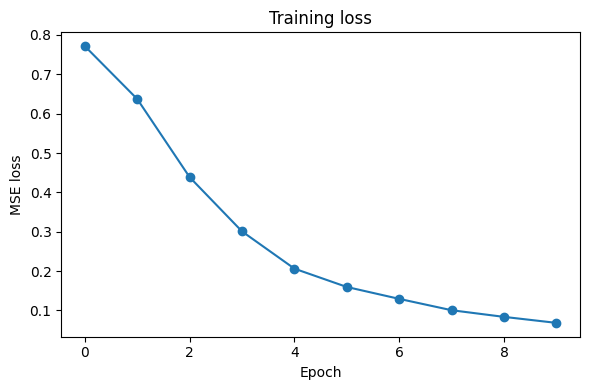


[Bước 5] Trích đặc trưng từ video kiểm tra

[Bước 6] Tạo chuỗi test

[Bước 7] Tính anomaly score
Ngưỡng phát hiện bất thường percentile 95: 0.107431

[Bước 8] Trực quan hóa kết quả


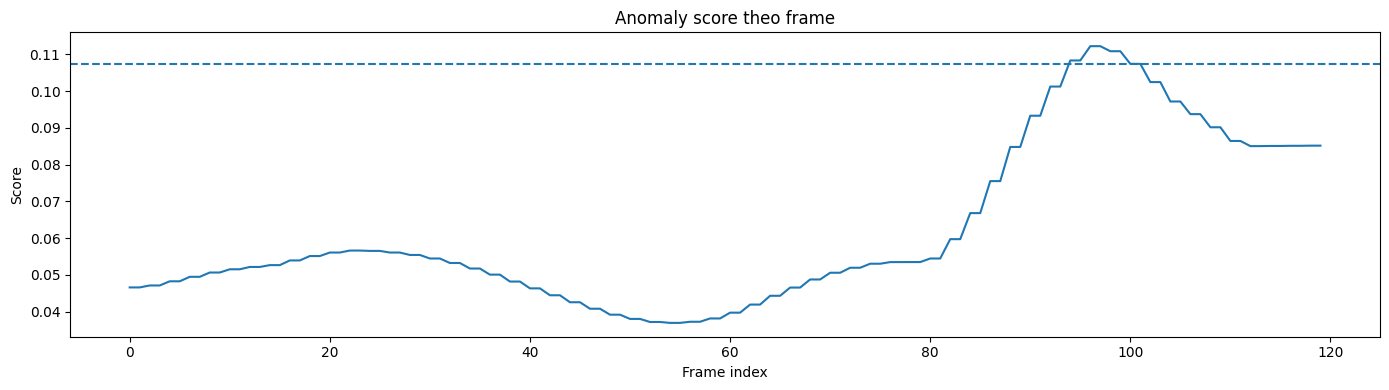

Đã lưu video: anomaly_annotated.mp4

[Bước 9] Kiểm tra kết quả
Thiết bị đang dùng: cpu
Kích thước đặc trưng train: (120, 512)
Kích thước chuỗi train: (53, 16, 512)
Kích thước đặc trưng test: (120, 512)
Kích thước chuỗi test: (53, 16, 512)
Số frame test: 120
Ngưỡng phát hiện: 0.10743082
Số frame được gán nhãn bất thường: 6
Kiểm tra kết quả: hợp lệ.

Hoàn tất.


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN BẤT THƯỜNG TRONG VIDEO BẰNG CNN + LSTM AUTOENCODER
# Chương/Mục liên quan: Chương 7 - Học sâu cho thị giác máy
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán phát hiện bất thường trong video.
# - Sử dụng CNN để trích đặc trưng từng frame.
# - Sử dụng LSTM Autoencoder để học quy luật thời gian của video bình thường.
# - Dùng lỗi tái tạo làm anomaly score.

# Sau khi chạy code, người học cần:
# 1. Quan sát được cách video được biến thành chuỗi đặc trưng.
# 2. Hiểu vai trò của CNN trong biểu diễn frame và LSTM trong mô hình hóa thời gian.
# 3. Thấy được frame bất thường thường có lỗi tái tạo lớn hơn.

# Input:
# - Video bình thường và video có bất thường từ GitHub.
# - Kiểu dữ liệu: video màu.

# Output:
# - Đồ thị training loss.
# - Đồ thị anomaly score theo frame.
# - Các frame có anomaly score cao nhất.
# - Video đầu ra có overlay nhãn NORMAL / ANOMALY.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import os
import cv2
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ============================================================
# 2. CẤU HÌNH THÍ NGHIỆM
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NORMAL_VIDEO_URL = "https://github.com/lthavnu/cv-book/raw/main/images/anomaly/normal.mp4"
ANOMALY_VIDEO_URL = "https://github.com/lthavnu/cv-book/raw/main/images/anomaly/anomaly.mp4"

DATA_DIR = "video_data"
TRAIN_NORMAL_VIDEO = os.path.join(DATA_DIR, "nomal.mp4")
TEST_VIDEO = os.path.join(DATA_DIR, "anomaly.mp4")

OUTPUT_VIDEO = "anomaly_annotated.mp4"
SCORE_PLOT = "anomaly_score_plot.png"
TOPK_FRAMES_DIR = "top_anomaly_frames"

IMG_SIZE = 224
SEQ_LEN = 16
STRIDE = 2
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-3
HIDDEN_DIM = 128
LATENT_DIM = 64
THRESHOLD_PERCENTILE = 95

# ============================================================
# 3. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def download_file(url, save_path):
    # Tải file từ URL nếu file chưa tồn tại.
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    if os.path.exists(save_path):
        print(f"Đã tồn tại: {save_path}")
        return

    print(f"Đang tải: {url}")
    urllib.request.urlretrieve(url, save_path)
    print(f"Đã lưu: {save_path}")

# ============================================================
# 4. TRÍCH ĐẶC TRƯNG FRAME BẰNG CNN
# ============================================================

class FrameFeatureExtractor:
    # Dùng ResNet18 pretrained để biến mỗi frame thành vector đặc trưng 512 chiều.

    def __init__(self, device=DEVICE):
        weights = models.ResNet18_Weights.DEFAULT
        backbone = models.resnet18(weights=weights)

        # Bỏ lớp phân loại cuối, chỉ giữ phần trích đặc trưng.
        self.feature_net = nn.Sequential(*list(backbone.children())[:-1]).to(device)
        self.feature_net.eval()
        self.device = device

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=weights.transforms().mean,
                std=weights.transforms().std
            )
        ])

    @torch.no_grad()
    def extract_from_video(self, video_path):
        # Đọc video và trích đặc trưng cho từng frame.
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            raise ValueError(f"Không mở được video: {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        features = []
        raw_frames = []

        while True:
            ret, frame = cap.read()

            if not ret:
                break

            raw_frames.append(frame.copy())

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            x = self.transform(rgb).unsqueeze(0).to(self.device)   # [1, 3, H, W]
            feat = self.feature_net(x)                             # [1, 512, 1, 1]
            feat = feat.flatten(1).squeeze(0).cpu().numpy()         # [512]

            features.append(feat)

        cap.release()

        features = np.array(features, dtype=np.float32)
        return features, raw_frames, fps, total_frames

# ============================================================
# 5. TẠO CHUỖI CON TỪ VIDEO
# ============================================================

def build_sequences(features, seq_len=SEQ_LEN, stride=STRIDE):
    # Biến dãy đặc trưng [T, D] thành các chuỗi con [seq_len, D].
    seqs = []
    indices = []

    T = len(features)

    for start in range(0, T - seq_len + 1, stride):
        end = start + seq_len
        seqs.append(features[start:end])
        indices.append((start, end - 1))

    return np.array(seqs, dtype=np.float32), indices


class SequenceDataset(Dataset):
    # Dataset PyTorch cho các chuỗi đặc trưng.

    def __init__(self, sequences):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

# ============================================================
# 6. XÂY DỰNG MÔ HÌNH LSTM AUTOENCODER
# ============================================================

class LSTMAutoencoder(nn.Module):
    # Encoder nén chuỗi đặc trưng thành vector ẩn.
    # Decoder tái tạo lại chuỗi từ vector ẩn đó.

    def __init__(self, input_dim=512, hidden_dim=128, latent_dim=64):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)

        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # x: [B, T, D]
        _, (h_n, _) = self.encoder(x)

        h = h_n[-1]                                # [B, H]
        z = self.to_latent(h)                      # [B, latent]
        dec_init = self.from_latent(z)             # [B, H]

        repeated = dec_init.unsqueeze(1).repeat(1, x.size(1), 1)  # [B, T, H]
        dec_out, _ = self.decoder(repeated)

        recon = self.output_layer(dec_out)         # [B, T, D]
        return recon

# ============================================================
# 7. HUẤN LUYỆN MÔ HÌNH
# ============================================================

def train_model(model, train_loader, epochs=EPOCHS, lr=LR, device=DEVICE):
    # Huấn luyện Autoencoder bằng MSE loss giữa chuỗi gốc và chuỗi tái tạo.
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            recon = model(batch)
            loss = criterion(recon, batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        losses.append(epoch_loss)

        print(f"Epoch {epoch + 1:02d}/{epochs} - loss: {epoch_loss:.6f}")

    return losses

# ============================================================
# 8. TÍNH ANOMALY SCORE
# ============================================================

@torch.no_grad()
def compute_sequence_scores(model, sequences, device=DEVICE):
    # Tính lỗi tái tạo cho từng chuỗi.
    model.eval()

    x = torch.tensor(sequences, dtype=torch.float32).to(device)
    recon = model(x)

    # Công thức chính:
    # anomaly_score = mean((recon - x)^2)
    mse = ((recon - x) ** 2).mean(dim=(1, 2)).cpu().numpy()

    return mse


def aggregate_scores_to_frames(seq_scores, seq_indices, total_frames):
    # Quy score từ mức chuỗi về mức frame bằng cách lấy trung bình.
    frame_scores = np.zeros(total_frames, dtype=np.float32)
    counts = np.zeros(total_frames, dtype=np.float32)

    for score, (start, end) in zip(seq_scores, seq_indices):
        frame_scores[start:end + 1] += score
        counts[start:end + 1] += 1

    counts[counts == 0] = 1
    frame_scores /= counts

    return frame_scores

# ============================================================
# 9. HIỂN THỊ VÀ LƯU KẾT QUẢ
# ============================================================

def plot_scores(frame_scores, threshold, save_path=SCORE_PLOT):
    # Vẽ anomaly score theo frame.
    plt.figure(figsize=(14, 4))
    plt.plot(frame_scores, linewidth=1.5)
    plt.axhline(threshold, linestyle="--", linewidth=1.5)
    plt.title("Anomaly score theo frame")
    plt.xlabel("Frame index")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def save_topk_anomaly_frames(frames, scores, k=8, out_dir=TOPK_FRAMES_DIR):
    # Lưu các frame có anomaly score cao nhất.
    os.makedirs(out_dir, exist_ok=True)

    top_idx = np.argsort(scores)[-k:][::-1]

    for rank, idx in enumerate(top_idx, start=1):
        frame = frames[idx].copy()
        text = f"rank={rank}, frame={idx}, score={scores[idx]:.4f}"

        cv2.putText(
            frame,
            text,
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

        cv2.imwrite(
            os.path.join(out_dir, f"top_{rank:02d}_frame_{idx:05d}.jpg"),
            frame
        )


def write_annotated_video(frames, scores, threshold, fps, save_path=OUTPUT_VIDEO):
    # Ghi video đầu ra có nhãn NORMAL / ANOMALY.
    h, w = frames[0].shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_path, fourcc, fps, (w, h))

    max_score = max(scores.max(), 1e-6)

    for i, frame in enumerate(frames):
        out = frame.copy()

        score = scores[i]
        is_anomaly = score >= threshold

        label = "ANOMALY" if is_anomaly else "NORMAL"
        color = (0, 0, 255) if is_anomaly else (0, 255, 0)

        cv2.putText(
            out,
            f"Frame: {i}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2
        )

        cv2.putText(
            out,
            f"Score: {score:.4f}",
            (20, 70),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

        cv2.putText(
            out,
            f"Label: {label}",
            (20, 105),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

        bar_w = 300
        filled = int(bar_w * min(score / max_score, 1.0))

        cv2.rectangle(out, (20, 130), (20 + bar_w, 155), (200, 200, 200), 2)
        cv2.rectangle(out, (20, 130), (20 + filled, 155), color, -1)

        writer.write(out)

    writer.release()

    print(f"Đã lưu video: {save_path}")

# ============================================================
# 10. KIỂM TRA KẾT QUẢ
# ============================================================

def check_results(train_features, train_seqs, test_features, test_seqs, frame_scores, threshold):
    # Kiểm tra kích thước dữ liệu và số lượng frame được gán nhãn bất thường.
    print("Thiết bị đang dùng:", DEVICE)
    print("Kích thước đặc trưng train:", train_features.shape)
    print("Kích thước chuỗi train:", train_seqs.shape)
    print("Kích thước đặc trưng test:", test_features.shape)
    print("Kích thước chuỗi test:", test_seqs.shape)
    print("Số frame test:", len(frame_scores))
    print("Ngưỡng phát hiện:", threshold)
    print("Số frame được gán nhãn bất thường:", np.sum(frame_scores >= threshold))

    assert train_features.ndim == 2
    assert test_features.ndim == 2
    assert train_seqs.ndim == 3
    assert test_seqs.ndim == 3
    assert len(frame_scores) == test_features.shape[0]

    print("Kiểm tra kết quả: hợp lệ.")

# ============================================================
# 11. CHƯƠNG TRÌNH CHÍNH
# ============================================================

def main():
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(TOPK_FRAMES_DIR, exist_ok=True)

    # Bước 1. Tải video từ URL.
    print("\n[Bước 1] Tải dữ liệu video")
    download_file(NORMAL_VIDEO_URL, TRAIN_NORMAL_VIDEO)
    download_file(ANOMALY_VIDEO_URL, TEST_VIDEO)

    # Bước 2. Trích đặc trưng từ video bình thường.
    print("\n[Bước 2] Trích đặc trưng từ video bình thường")
    extractor = FrameFeatureExtractor(device=DEVICE)
    train_features, _, _, _ = extractor.extract_from_video(TRAIN_NORMAL_VIDEO)

    # Bước 3. Tạo các chuỗi con để huấn luyện.
    print("\n[Bước 3] Tạo chuỗi train")
    train_seqs, _ = build_sequences(train_features, seq_len=SEQ_LEN, stride=STRIDE)

    train_ds = SequenceDataset(train_seqs)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # Bước 4. Huấn luyện LSTM Autoencoder.
    print("\n[Bước 4] Huấn luyện LSTM Autoencoder")

    model = LSTMAutoencoder(
        input_dim=train_features.shape[1],
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM
    ).to(DEVICE)

    losses = train_model(model, train_loader, epochs=EPOCHS, lr=LR, device=DEVICE)

    plt.figure(figsize=(6, 4))
    plt.plot(losses, marker="o")
    plt.title("Training loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.tight_layout()
    plt.show()

    # Bước 5. Trích đặc trưng từ video kiểm tra.
    print("\n[Bước 5] Trích đặc trưng từ video kiểm tra")
    test_features, test_frames, fps, total_frames = extractor.extract_from_video(TEST_VIDEO)

    # Bước 6. Tạo chuỗi test.
    print("\n[Bước 6] Tạo chuỗi test")
    test_seqs, test_indices = build_sequences(test_features, seq_len=SEQ_LEN, stride=STRIDE)

    # Bước 7. Tính anomaly score.
    print("\n[Bước 7] Tính anomaly score")
    seq_scores = compute_sequence_scores(model, test_seqs, device=DEVICE)
    frame_scores = aggregate_scores_to_frames(seq_scores, test_indices, total_frames)

    threshold = np.percentile(frame_scores, THRESHOLD_PERCENTILE)

    print(f"Ngưỡng phát hiện bất thường percentile {THRESHOLD_PERCENTILE}: {threshold:.6f}")

    # Bước 8. Trực quan hóa và lưu kết quả.
    print("\n[Bước 8] Trực quan hóa kết quả")
    plot_scores(frame_scores, threshold, save_path=SCORE_PLOT)
    save_topk_anomaly_frames(test_frames, frame_scores, k=8, out_dir=TOPK_FRAMES_DIR)
    write_annotated_video(test_frames, frame_scores, threshold, fps, save_path=OUTPUT_VIDEO)

    # Bước 9. Kiểm tra kết quả.
    print("\n[Bước 9] Kiểm tra kết quả")
    check_results(
        train_features,
        train_seqs,
        test_features,
        test_seqs,
        frame_scores,
        threshold
    )

    print("\nHoàn tất.")

# ============================================================
# 12. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi SEQ_LEN, ví dụ 8, 16, 32, để quan sát ảnh hưởng của độ dài chuỗi thời gian.
# 2. Thay đổi STRIDE, ví dụ 1, 2, 4, để quan sát mức độ chồng lấn giữa các chuỗi.
# 3. Thay đổi THRESHOLD_PERCENTILE, ví dụ 90, 95, 98, để quan sát số frame bị gán nhãn bất thường.

if __name__ == "__main__":
    main()